# 5-fold CV: orig / clean

Outer `StratifiedKFold(n=5, seed=42)` holds out 20% as test. From the remaining 80%, a stratified 1/8 split is val, so each fold is **70/10/20**. Per-fold seed is `42 + fold`.

This rerun **reuses** `results/splits/{variant}-fold{k}.csv` and does **not** overwrite the published `results/kfold.csv`. New artifacts:

- `results/history/{variant}-fold{k}.csv` — per-epoch train/val loss and accuracy
- `results/kfold_scores.csv` — restored-weight train / val / test loss and accuracy

Set `FORCE = True` to retrain even if a history file already exists. Default jobs are **clean** folds only.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

HERE = Path.cwd()
if HERE.name != "cnn-latest":
    HERE = Path("training/notebooks/cnn-latest").resolve()

KFOLD_CSV = HERE / "results" / "kfold.csv"
SCORES_CSV = HERE / "results" / "kfold_scores.csv"
HIST = HERE / "results" / "history"

VARIANT = "clean"
FOLDS = list(range(5))
FORCE = True

display(pd.DataFrame(
    [
        {"key": "variant", "value": VARIANT},
        {"key": "folds", "value": FOLDS},
        {"key": "force", "value": FORCE},
        {"key": "published", "value": str(KFOLD_CSV)},
        {"key": "scores", "value": str(SCORES_CSV)},
    ]
))

,key,value
0,variant,clean
1,folds,"[0, 1, 2, 3, 4]"
2,force,True
3,published,/home/seya/code/chord-detection/training/noteb...
4,scores,/home/seya/code/chord-detection/training/noteb...


## Train folds

Each fold is an isolated `run_kfold.py` process. Histories already on disk are skipped unless `FORCE` is true.

In [2]:
import subprocess

from IPython.display import Markdown

jobs = [(VARIANT, f) for f in FOLDS]
pending = []
for variant, fold in jobs:
    hist = HIST / f"{variant}-fold{fold}.csv"
    if FORCE or not hist.is_file():
        pending.append((variant, fold))

display(Markdown(f"Pending **{len(pending)}** / {len(jobs)}"))

for variant, fold in pending:
    display(Markdown(f"### `{variant}` fold {fold}"))
    cmd = ["uv", "run", "python", "run_kfold.py", "--variant", variant, "--fold", str(fold)]
    if FORCE:
        cmd.append("--force")
    result = subprocess.run(cmd, cwd=HERE, check=False)
    if result.returncode != 0:
        raise RuntimeError(f"{variant}/fold{fold} exited {result.returncode}")

Pending **5** / 5

### `clean` fold 0

Using GPU: NVIDIA GeForce RTX 2080 Ti


reusing clean-fold0.csv


I0000 00:00:1787643293.591244   83909 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

### `clean` fold 4

Using GPU: NVIDIA GeForce RTX 2080 Ti


reusing clean-fold4.csv


I0000 00:00:1787644017.352431   92788 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


published test_accuracy 1.000000  rerun 1.000000  delta +0.000000
OK clean/fold4: {'variant': 'clean', 'fold': 4, 'seed': 46, 'n_train': 5020, 'n_val': 718, 'n_test': 1434, 'epochs_run': 10, 'train_loss': 1.2225013051647693e-05, 'train_accuracy': 1.0, 'val_loss': 0.0013438633177429438, 'val_accuracy': 1.0, 'test_loss': 1.345002544894669e-07, 'test_accuracy': 1.0, 'test_macro_precision': 1.0, 'test_macro_recall': 1.0, 'test_macro_f1': 1.0}


## Fold scores

Restored-weight train / val / test loss and accuracy from `kfold_scores.csv`. Published `kfold.csv` is shown only as a test-accuracy check and is not written.

In [3]:
from IPython.display import Markdown


def with_mean_std(df, label_col):
    mean = df.drop(columns=[label_col]).mean(numeric_only=True)
    std = df.drop(columns=[label_col]).std(numeric_only=True, ddof=1)
    out = df.copy()
    out.loc[len(out)] = {label_col: "mean", **mean.to_dict()}
    out.loc[len(out)] = {label_col: "std", **std.to_dict()}
    return out

assert SCORES_CSV.is_file(), f"missing {SCORES_CSV} — run the train-folds cell first"
scores = pd.read_csv(SCORES_CSV)
scores = scores[scores.variant == VARIANT].sort_values("fold").reset_index(drop=True)

metrics = pd.DataFrame(
    {
        "fold": [f"Fold {int(f) + 1}" for f in scores.fold],
        "train_accuracy": scores.train_accuracy,
        "train_loss": scores.train_loss,
        "val_accuracy": scores.val_accuracy,
        "val_loss": scores.val_loss,
        "test_accuracy": scores.test_accuracy,
        "test_loss": scores.test_loss,
    }
)
display(Markdown("**Restored weights** — train / val / test"))
display(with_mean_std(metrics, "fold").round(6))

pub = pd.read_csv(KFOLD_CSV)
pub = pub[pub.variant == VARIANT].sort_values("fold")
cmp = pd.DataFrame(
    {
        "fold": [f"Fold {int(f) + 1}" for f in scores.fold],
        "published_test_accuracy": pub.test_accuracy.to_numpy(),
        "rerun_test_accuracy": scores.test_accuracy.to_numpy(),
    }
)
cmp["delta"] = cmp.rerun_test_accuracy - cmp.published_test_accuracy
display(Markdown("**Published `kfold.csv` vs this rerun** (not overwritten)"))
display(cmp.round(6))

**Restored weights** — train / val / test

,fold,train_accuracy,train_loss,val_accuracy,val_loss,test_accuracy,test_loss
0,Fold 1,1.0,0.000001,1.0,0.001421,1.000000,0.000000
1,Fold 2,1.0,0.000036,1.0,0.000000,1.000000,0.000025
2,Fold 3,1.0,0.000005,1.0,0.000000,0.999303,0.001394
3,Fold 4,1.0,0.000006,1.0,0.000000,1.000000,0.000445
4,Fold 5,1.0,0.000012,1.0,0.001344,1.000000,0.000000
5,mean,1.0,0.000012,1.0,0.000553,0.999861,0.000373
6,std,0.0,0.000014,0.0,0.000758,0.000312,0.000602


**Published `kfold.csv` vs this rerun** (not overwritten)

,fold,published_test_accuracy,rerun_test_accuracy,delta
0,Fold 1,1.000000,1.000000,0.0
1,Fold 2,1.000000,1.000000,0.0
2,Fold 3,0.999303,0.999303,-0.0
3,Fold 4,1.000000,1.000000,0.0
4,Fold 5,1.000000,1.000000,0.0


## Combined training history

All five clean folds on one pair of axes. Solid = training, dashed = validation. Open circles mark the best validation-loss epoch (the restored weights).

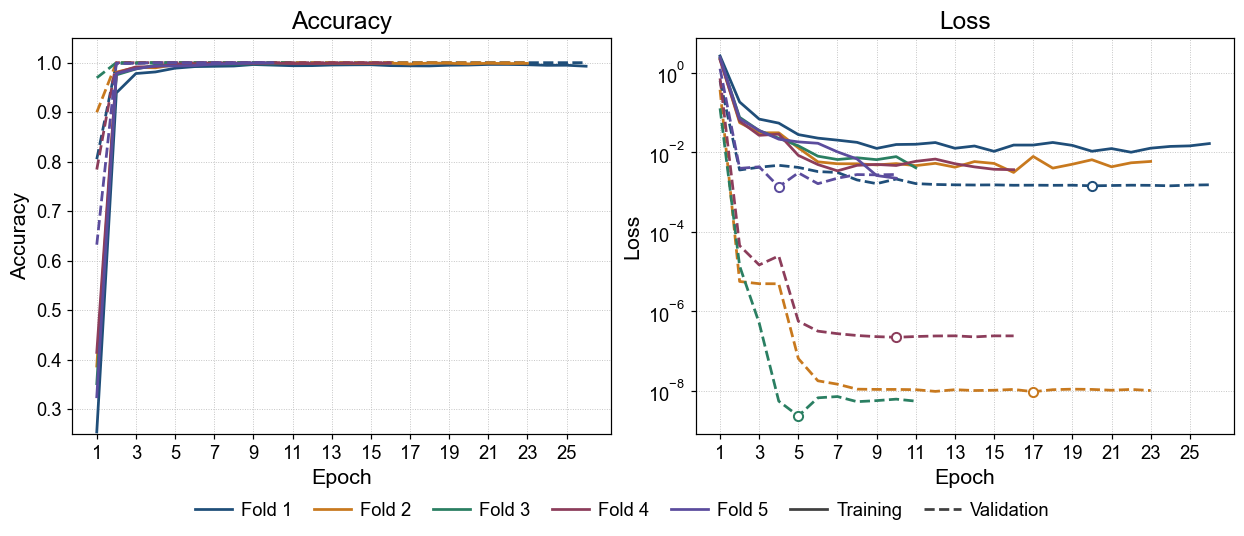

In [4]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

NAVY = "#1f4e79"
ACCENT = "#c8791e"
FOLD_COLORS = ["#1f4e79", "#c8791e", "#2a7f62", "#8c3d5b", "#5b4c9d"]

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.frameon": False,
    "figure.dpi": 110,
})

hists = []
for fold in FOLDS:
    path = HIST / f"{VARIANT}-fold{fold}.csv"
    assert path.is_file(), path
    h = pd.read_csv(path)
    hists.append(h)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.8), layout="constrained")
for h, color, fold in zip(hists, FOLD_COLORS, FOLDS):
    label = f"Fold {fold + 1}"
    axes[0].plot(h.epoch, h.accuracy, color=color, linewidth=1.8, label=label)
    axes[0].plot(h.epoch, h.val_accuracy, color=color, linewidth=1.8, linestyle="--")
    axes[1].plot(h.epoch, h.loss, color=color, linewidth=1.8)
    axes[1].plot(h.epoch, h.val_loss, color=color, linewidth=1.8, linestyle="--")
    best = h.loc[h.val_loss.idxmin()]
    axes[1].scatter(
        [best.epoch], [best.val_loss], s=36, facecolor="white",
        edgecolor=color, linewidth=1.3, zorder=4,
    )

axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.25, 1.05)
axes[0].set_title("Accuracy")
axes[1].set_ylabel("Loss")
axes[1].set_yscale("log")
axes[1].set_title("Loss")
max_epoch = max(int(h.epoch.max()) for h in hists)
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_axisbelow(True)
    ax.grid(True, linestyle=":", linewidth=0.6, color="0.75")
    ax.set_xticks(np.arange(1, max_epoch + 1, 2 if max_epoch > 16 else 1))

fold_handles = [
    Line2D([], [], color=c, linewidth=1.8, label=f"Fold {i + 1}")
    for i, c in enumerate(FOLD_COLORS)
]
style_handles = [
    Line2D([], [], color="0.25", linewidth=1.8, label="Training"),
    Line2D([], [], color="0.25", linewidth=1.8, linestyle="--", label="Validation"),
]
fig.legend(
    handles=fold_handles + style_handles,
    loc="outside lower center", ncol=7, columnspacing=1.2, handletextpad=0.5,
)
plt.show()

## Per-fold epoch tables

Train and validation only — test is scored once after restore, in the table above.

In [5]:
for fold in FOLDS:
    h = pd.read_csv(HIST / f"{VARIANT}-fold{fold}.csv")
    display(Markdown(f"**Fold {fold + 1}** (seed {42 + fold})"))
    cols = [c for c in ["epoch", "loss", "accuracy", "val_loss", "val_accuracy", "lr"] if c in h.columns]
    display(h[cols].round(6))

**Fold 1** (seed 42)

,epoch,loss,accuracy,val_loss,val_accuracy,lr
0,1,2.619047,0.254035,0.614175,0.805014,0.001000
1,2,0.182025,0.939032,0.003550,0.998607,0.001000
2,3,0.067592,0.978083,0.004167,0.998607,0.001000
3,4,0.053549,0.981271,0.004651,1.000000,0.001000
4,5,0.027542,0.988842,0.004119,1.000000,0.000100
5,6,0.022451,0.992030,0.003238,1.000000,0.000100
6,7,0.019972,0.992628,0.003075,1.000000,0.000100
7,8,0.017574,0.993226,0.001994,1.000000,0.000100
8,9,0.012393,0.996214,0.001611,1.000000,0.000100
9,10,0.015512,0.995019,0.002101,1.000000,0.000100


**Fold 2** (seed 43)

,epoch,loss,accuracy,val_loss,val_accuracy,lr
0,1,2.175020,0.387129,0.369554,0.899721,0.001000
1,2,0.054961,0.980873,0.000006,1.000000,0.001000
2,3,0.030608,0.990436,0.000005,1.000000,0.001000
3,4,0.030563,0.989639,0.000005,1.000000,0.001000
4,5,0.012797,0.995816,0.000000,1.000000,0.000100
5,6,0.005691,0.998605,0.000000,1.000000,0.000100
6,7,0.005090,0.998008,0.000000,1.000000,0.000010
7,8,0.005089,0.998406,0.000000,1.000000,0.000010
8,9,0.004763,0.998406,0.000000,1.000000,0.000001
9,10,0.005139,0.998805,0.000000,1.000000,0.000001


**Fold 3** (seed 44)

,epoch,loss,accuracy,val_loss,val_accuracy,lr
0,1,2.295757,0.351594,0.125942,0.969359,0.001000
1,2,0.074840,0.975299,0.000014,1.000000,0.001000
2,3,0.034808,0.987251,0.000001,1.000000,0.001000
3,4,0.022327,0.995020,0.000000,1.000000,0.001000
4,5,0.014374,0.995618,0.000000,1.000000,0.000100
5,6,0.007893,0.997410,0.000000,1.000000,0.000100
6,7,0.006501,0.997610,0.000000,1.000000,0.000010
7,8,0.007204,0.997012,0.000000,1.000000,0.000010
8,9,0.006454,0.997410,0.000000,1.000000,0.000001
9,10,0.007698,0.997410,0.000000,1.000000,0.000001


**Fold 4** (seed 45)

,epoch,loss,accuracy,val_loss,val_accuracy,lr
0,1,2.088675,0.414741,0.712962,0.784123,0.001000
1,2,0.060471,0.979283,0.000045,1.000000,0.001000
2,3,0.026380,0.991434,0.000015,1.000000,0.001000
3,4,0.028246,0.991833,0.000025,1.000000,0.001000
4,5,0.008268,0.997211,0.000001,1.000000,0.000100
5,6,0.004857,0.998207,0.000000,1.000000,0.000100
6,7,0.003379,0.999203,0.000000,1.000000,0.000010
7,8,0.004645,0.998606,0.000000,1.000000,0.000010
8,9,0.004891,0.998406,0.000000,1.000000,0.000001
9,10,0.004602,0.999004,0.000000,1.000000,0.000001


**Fold 5** (seed 46)

,epoch,loss,accuracy,val_loss,val_accuracy,lr
0,1,2.403025,0.325100,1.248011,0.632312,0.00100
1,2,0.069155,0.977888,0.003899,0.998607,0.00100
2,3,0.034867,0.987649,0.004260,0.998607,0.00100
3,4,0.021117,0.993426,0.001344,1.000000,0.00100
4,5,0.018051,0.993227,0.003016,1.000000,0.00100
5,6,0.016662,0.994223,0.001606,1.000000,0.00100
6,7,0.010130,0.997012,0.002206,1.000000,0.00010
7,8,0.006714,0.998008,0.002723,1.000000,0.00010
8,9,0.002572,0.999402,0.002679,1.000000,0.00001
9,10,0.002206,0.999602,0.002736,1.000000,0.00001
